<a href="https://colab.research.google.com/github/Jesus4antonio/Probabilidad/blob/main/Unidad6/An%C3%A1lisis_Estad%C3%ADstico_de_Datos_COVID_19_en_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBABILIDAD Y ESTADISTICA

## UNIDAD 6

### FACILITADOR: Jose Gabriel Rodruguez

### Alumnos: Jesus Antonio Sanchez Aguilar,Francisco Valdez Zuñiga,Valentín Herrera Carrera

## **Análisis Estadístico de Datos COVID-19 en Python**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TU_USUARIO/TU_REPOSITORIO/blob/main/Proyecto_Final.ipynb)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_4679/171770603.py:11: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_datos)


Estructura inicial de los datos cargados:
   SECTOR       SEXO       ENTIDAD_NAC TIPO_PACIENTE FECHA_INGRESO  \
0  Issste   Femenino   San Luis Potosí   Ambulatorio    2020-12-06   
1  Issste  Masculino   San Luis Potosí   Ambulatorio    2020-02-20   
2     Ssa   Femenino           Jalisco   Ambulatorio    2020-04-22   
3     Ssa  Masculino         Chihuahua   Ambulatorio    2020-07-28   
4     Ssa  Masculino  Ciudad De México   Ambulatorio    2020-08-18   

    FECHA_DEF   INTUBADO NEUMONIA  EDAD   EMBARAZO  ... DIABETES EPOC ASMA  \
0  9999-99-99  No aplica       No    55         No  ...       Si   No   No   
1  9999-99-99  No aplica       No    59  No aplica  ...       No   No   No   
2  9999-99-99  No aplica       No    42         No  ...       No   No   Si   
3  9999-99-99  No aplica       No    35  No aplica  ...       No   No   No   
4  9999-99-99  No aplica       No    51  No aplica  ...       No   No   No   

  HIPERTENSION CARDIOVASCULAR OBESIDAD RENAL_CRONICA TABAQUISMO  \
0

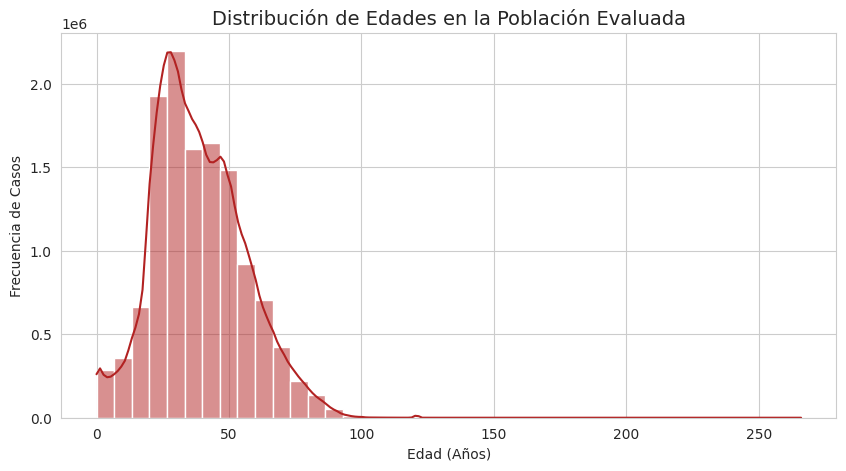

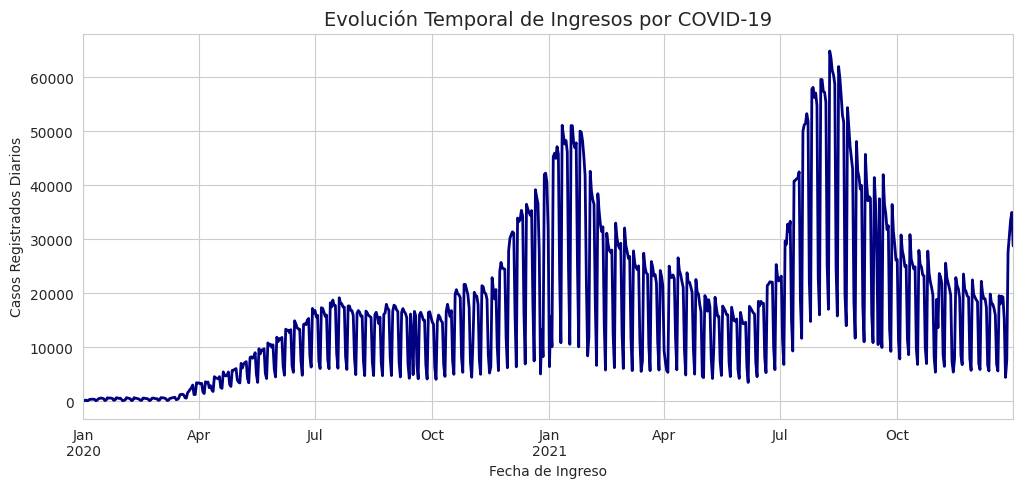

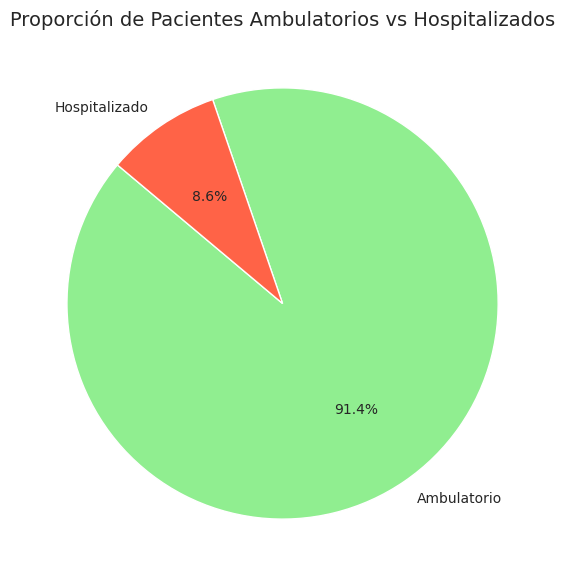

/tmp/ipykernel_4679/171770603.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  conteo_medico = [df[c].value_counts().get(1, 0) for c in comorbilidades_presentes]
/tmp/ipykernel_4679/171770603.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  conteo_medico = [df[c].value_counts().get(1, 0) for c in comorbilidades_presentes]
/tmp/ipykernel_4679/171770603.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  conteo_medico = [df[c

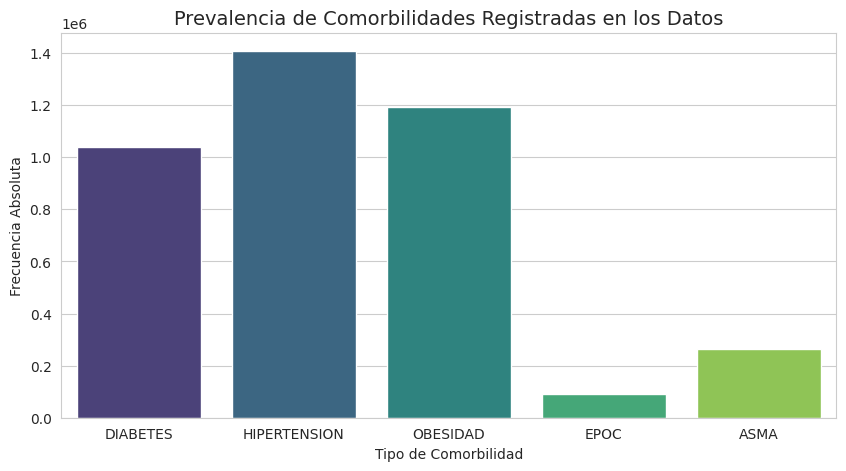

/tmp/ipykernel_4679/171770603.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  casos_con_enfermedad = df[c].value_counts().get(1, 0)



 PROBABILIDADES ASOCIADAS A COMORBILIDADES
Probabilidad de que un paciente padezca DIABETES: 0.082194 (8.2194%)
Probabilidad de que un paciente padezca HIPERTENSION: 0.111426 (11.1426%)


/tmp/ipykernel_4679/171770603.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  casos_con_enfermedad = df[c].value_counts().get(1, 0)
/tmp/ipykernel_4679/171770603.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  casos_con_enfermedad = df[c].value_counts().get(1, 0)
/tmp/ipykernel_4679/171770603.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  casos_con_enfermedad = df[c].value_counts().get(1, 0)
/tmp/ipykernel_4679/17

Probabilidad de que un paciente padezca OBESIDAD: 0.094428 (9.4428%)
Probabilidad de que un paciente padezca EPOC: 0.007317 (0.7317%)
Probabilidad de que un paciente padezca ASMA: 0.020884 (2.0884%)

 CÁLCULO DE PROBABILIDAD (DISTRIBUCIÓN NORMAL)
La probabilidad de que un estado registre entre 2000 y 3000 casos es de: 0.507910
Expresado en porcentaje: 50.79%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from google.colab import drive

drive.mount('/content/drive')

ruta_datos = '/content/drive/MyDrive/Colab Notebooks/covid2020-2021-codificado.csv'
df = pd.read_csv(ruta_datos)

df.columns = df.columns.str.upper().str.strip()

print("Estructura inicial de los datos cargados:")
print(df.head())

col_clasificacion = 'CLASIFICACION_FINAL' if 'CLASIFICACION_FINAL' in df.columns else (df.columns[df.columns.str.contains('CLASIF')][0] if df.columns.str.contains('CLASIF').any() else None)
col_paciente = 'TIPO_PACIENTE' if 'TIPO_PACIENTE' in df.columns else (df.columns[df.columns.str.contains('PACIENTE')][0] if df.columns.str.contains('PACIENTE').any() else None)
col_embarazo = 'EMBARAZO' if 'EMBARAZO' in df.columns else (df.columns[df.columns.str.contains('EMBARA')][0] if df.columns.str.contains('EMBARA').any() else None)
col_indigena = 'INDIGENA' if 'INDIGENA' in df.columns else (df.columns[df.columns.str.contains('INDIG')][0] if df.columns.str.contains('INDIG').any() else None)
col_entidad = 'ENTIDAD_RES' if 'ENTIDAD_RES' in df.columns else ('ENTIDAD_UM' if 'ENTIDAD_UM' in df.columns else ('ENTIDAD_FEDERATIVA' if 'ENTIDAD_FEDERATIVA' in df.columns else None))
col_fecha = 'FECHA_INGRESO' if 'FECHA_INGRESO' in df.columns else ('FECHA_SINTOMAS' if 'FECHA_SINTOMAS' in df.columns else ('FECHA_ACTUALIZACION' if 'FECHA_ACTUALIZACION' in df.columns else None))
col_sexo = 'SEXO' if 'SEXO' in df.columns else None
col_edad = 'EDAD' if 'EDAD' in df.columns else None

print("\n" + "="*60)
print(" DESPLIEGUE DE ESTADÍSTICA DESCRIPTIVA OBLIGATORIA")
print("="*60)

if col_clasificacion:
    print("\n[Casos por Clasificación Final]:")
    print(df[col_clasificacion].value_counts())

if col_paciente:
    print("\n[Tipo de Paciente (Ambulatorio vs Hospitalizado)]:")
    print(df[col_paciente].value_counts())

if col_embarazo:
    print("\n[Conteo de Pacientes Embarazadas]:")
    print(df[col_embarazo].value_counts())

if col_indigena:
    print("\n[Conteo de Pacientes Indígenas]:")
    print(df[col_indigena].value_counts())

sns.set_style("whitegrid")

if col_entidad:
    plt.figure(figsize=(12, 8))
    df[col_entidad].value_counts().plot(kind='barh', color='darkcyan')
    plt.title('Número de Casos Reportados por Estado / Entidad', fontsize=14)
    plt.xlabel('Cantidad Absoluta de Casos')
    plt.ylabel('Entidad Federativa')
    plt.tight_layout()
    plt.show()

if col_edad:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col_edad], bins=40, kde=True, color='firebrick')
    plt.title('Distribución de Edades en la Población Evaluada', fontsize=14)
    plt.xlabel('Edad (Años)')
    plt.ylabel('Frecuencia de Casos')
    plt.show()

if col_fecha:
    plt.figure(figsize=(12, 5))
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    casos_temporales = df.groupby(col_fecha).size()
    casos_temporales.plot(kind='line', color='navy', linewidth=2)
    plt.title('Evolución Temporal de Ingresos por COVID-19', fontsize=14)
    plt.xlabel('Fecha de Ingreso')
    plt.ylabel('Casos Registrados Diarios')
    plt.show()

if col_sexo and col_clasificacion:
    plt.figure(figsize=(10, 6))
    tabla_sexo_res = pd.crosstab(df[col_sexo], df[col_clasificacion])
    tabla_sexo_res.plot(kind='bar', stacked=True, colormap='plasma', figsize=(10, 6))
    plt.title('Distribución de Resultados Clínicos por Sexo', fontsize=14)
    plt.xlabel('Sexo del Paciente')
    plt.ylabel('Total de Casos')
    plt.legend(title='Resultado Final')
    plt.show()

if col_paciente:
    plt.figure(figsize=(7, 7))
    df[col_paciente].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'tomato'], startangle=140)
    plt.title('Proporción de Pacientes Ambulatorios vs Hospitalizados', fontsize=14)
    plt.ylabel('')
    plt.show()

comorbilidades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA', 'INMUNOSUPR']
comorbilidades_presentes = [c for c in comorbilidades if c in df.columns]

if comorbilidades_presentes:
    plt.figure(figsize=(10, 5))
    conteo_medico = [df[c].value_counts().get(1, 0) for c in comorbilidades_presentes]
    sns.barplot(x=comorbilidades_presentes, y=conteo_medico, palette='viridis')
    plt.title('Prevalencia de Comorbilidades Registradas en los Datos', fontsize=14)
    plt.xlabel('Tipo de Comorbilidad')
    plt.ylabel('Frecuencia Absoluta')
    plt.show()

print("\n" + "="*60)
print(" PROBABILIDADES ASOCIADAS A COMORBILIDADES")
print("="*60)

total_registros = len(df)
for c in comorbilidades_presentes:
    casos_con_enfermedad = df[c].value_counts().get(1, 0)
    prob = casos_con_enfermedad / total_registros
    print(f"Probabilidad de que un paciente padezca {c}: {prob:.6f} ({prob*100:.4f}%)")

print("\n" + "="*60)
print(" CÁLCULO DE PROBABILIDAD (DISTRIBUCIÓN NORMAL)")
print("="*60)

mu = 2360
sigma = 714
lim_inf = 2000
lim_sup = 3000

cdf_inferior = stats.norm.cdf(lim_inf, mu, sigma)
cdf_superior = stats.norm.cdf(lim_sup, mu, sigma)
probabilidad_rango = cdf_superior - cdf_inferior

print(f"La probabilidad de que un estado registre entre 2000 y 3000 casos es de: {probabilidad_rango:.6f}")
print(f"Expresado en porcentaje: {probabilidad_rango*100:.2f}%")